# RNN 
- 2 Entradas PwmD, PwmE
- 2 Saidas Wd e We
- 1 Camada
- n neurônios
## Resultados
- 0.89 R² teste We
- 0.93 R² teste Wd

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["PwmD", "PwmE"]   
TARGET = ["X", "Y", "Theta"]       
TIME_STEPS = 3

for i in range(4):
    Dataset = pd.read_excel(f"../../RotedData/Data.xlsx", f"D{i+1}")   
    # Criar as colunas de deltas automaticamente
    for var in TARGET:
        Dataset[f"Delta{var}"] = Dataset[var].shift(-1) - Dataset[var]    
           
    Datasets.append(Dataset)

for i in range(2):   
    Dataset = pd.read_csv(f"../../RotedData/Data{i + 1}.csv")
        
    # Criar as colunas de deltas automaticamente
    for var in TARGET:
        Dataset[f"Delta{var}"] = Dataset[var].shift(-1) - Dataset[var]    
    
    Datasets.append(Dataset)
    

for i in range(len(Datasets)):
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Dataset.head(5))



++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
     X    Y  Theta    Wd   We  WdRef  WeRef   PwmD   PwmE  DeltaX  DeltaY  \
0  0.0  0.7    0.0  0.00  0.0  -0.00   0.00  -0.00   0.00     0.0     0.0   
1  0.0  0.7    0.0  0.00  0.0   3.28   3.28  -0.00   0.00     0.0     0.0   
2  0.0  0.7    0.0  0.00  0.0   3.28   3.28  49.25  49.25     0.0     0.0   
3  0.0  0.7    0.0  0.14  0.0   3.28   3.28  49.25  49.25     0.0     0.0   
4  0.0  0.7    0.0  0.00  0.0   3.27   3.27  66.69  68.80     0.0     0.0   

   DeltaTheta  
0         0.0  
1         0.0  
2         0.0  
3         0.0  
4        -0.0  
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
     X    Y  Theta    Wd   We  WdRef  WeRef   PwmD   PwmE  DeltaX  DeltaY  \
0  0.0  0.7    0.0  0.00  0.0  -0.00   0.00  -0.00   0.00     0.0     0.0   
1  0.0  0.7    0.0  0.00  0.0   3.28   3.28  -0.00   0.00     0.0     0.0   
2  0.0  0.7    0.0  0.00  0.0   3.28   3.28  49.25  49.25     0.0     0.0   
3  0.0  0.7    0.0  0.1

In [2]:
NormDatasets = []
TARGET = ["DeltaTheta", "DeltaX", "DeltaY"]

SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset1 = Datasets[0]
TrainDataset1[PREDICTORS] = SCALER.fit_transform(TrainDataset1[PREDICTORS])
TrainDataset1[TARGET] = OUT_SCALER.fit_transform(TrainDataset1[TARGET])
NormDatasets.append(TrainDataset1)


TrainDataset2 = Datasets[1]
TrainDataset2[PREDICTORS] = SCALER.fit_transform(TrainDataset2[PREDICTORS])
TrainDataset2[TARGET] = OUT_SCALER.fit_transform(TrainDataset2[TARGET])
NormDatasets.append(TrainDataset2)

for i in range(4):
      CurrentTestDataset = Datasets[i + 2]
      CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
      CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])
      NormDatasets.append(CurrentTestDataset)
      print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
      print(NormDatasets[i].head(5))

++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
   Unnamed: 0    X    Y  Theta    Wd   We  WdRef  WeRef      PwmD      PwmE  \
0        0.00  0.0  0.7   0.00  0.00  0.0   0.00   0.00  0.221897  0.111793   
1        0.07  0.0  0.7   0.00  0.00  0.0   3.28   3.28  0.221897  0.111793   
2        0.14  0.0  0.7   0.00  0.00  0.0   3.28   3.28  0.803731  0.594153   
3        0.21  0.0  0.7   0.00  0.06  0.0   3.28   3.28  0.803731  0.594153   
4        0.28  0.0  0.7   0.01  0.33  0.0   3.28   3.28  1.026068  0.786705   

     DeltaX   DeltaY  DeltaTheta  
0 -0.001615  0.00264    0.045457  
1 -0.001615  0.00264    0.045457  
2 -0.001615  0.00264    0.045457  
3 -0.001615  0.00264    0.600031  
4 -0.001615  0.00264    0.045457  
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
   Unnamed: 0     X     Y  Theta   Wd   We  WdRef  WeRef      PwmD      PwmE  \
0        0.00  0.01  0.69   -0.8  0.0  0.0   0.85   2.03 -0.266248  0.128448   
1        0.07  0.01  

In [3]:
def CreateSequencesMultiTrajectory(datasets, predictors, target, timesteps):
    """
    datasets: lista de DataFrames (uma trajetória por DataFrame)
    predictors: lista de colunas de entrada
    target: lista de colunas de saída
    timesteps: janela temporal
    """
    X_all, Y_all = [], []

    for data in datasets:
        X_seq, Y_seq = [], []

        x_data = data[predictors]
        y_data = data[target]

        for i in range(timesteps, len(x_data)):
            X_seq.append(x_data.iloc[i-timesteps:i].values)
            Y_seq.append(y_data.iloc[i].values)

        X_all.append(np.array(X_seq))
        Y_all.append(np.array(Y_seq))

    return np.array(X_all), np.array(Y_all)


In [4]:
TrainDatasets = [NormDatasets[0], NormDatasets[1]]
TestDatasets = [NormDatasets[2], NormDatasets[3]]
ValDataset = [NormDatasets[4], NormDatasets[5]]

x_train, y_train = CreateSequencesMultiTrajectory(
    datasets=TrainDatasets,
    predictors=PREDICTORS,
    target=TARGET,
    timesteps=TIME_STEPS
)

x_test, y_test = CreateSequencesMultiTrajectory(
    datasets=TestDatasets,
    predictors=PREDICTORS,
    target=TARGET,
    timesteps=TIME_STEPS
)


x_val, y_val = CreateSequencesMultiTrajectory(
    datasets=ValDataset,
    predictors=PREDICTORS,
    target=TARGET,
    timesteps=TIME_STEPS
)

print(f"Dimensão da entrada (train): {np.shape(x_train)}")
print(f"Dimensão da saida (train): {np.shape(y_train)}")

print(f"Dimensão da entrada (test): {np.shape(x_test)}")
print(f"Dimensão da saida (test): {np.shape(y_test)}")

print(f"Dimensão da entrada (val): {np.shape(x_val)}")
print(f"Dimensão da saida (val): {np.shape(y_val)}")

Dimensão da entrada (train): (2, 974, 3, 2)
Dimensão da saida (train): (2, 974, 3)
Dimensão da entrada (test): (2, 980, 3, 2)
Dimensão da saida (test): (2, 980, 3)
Dimensão da entrada (val): (2, 1951, 3, 2)
Dimensão da saida (val): (2, 1951, 3)


In [5]:

x_train = x_train.reshape(-1, TIME_STEPS, len(PREDICTORS))
y_train = y_train.reshape(-1, len(TARGET))

x_val = x_val.reshape(-1, TIME_STEPS, len(PREDICTORS))
y_val = y_val.reshape(-1, len(TARGET))

x_test = x_test.reshape(-1, TIME_STEPS, len(PREDICTORS))
y_test = y_test.reshape(-1, len(TARGET))


print(f"Dimensão da entrada (train): {np.shape(x_train)}")
print(f"Dimensão da saida (train): {np.shape(y_train)}")


print(f"Dimensão da entrada (test): {np.shape(x_test)}")
print(f"Dimensão da saida (test): {np.shape(y_test)}")


print(f"Dimensão da entrada (val): {np.shape(x_val)}")
print(f"Dimensão da saida (val): {np.shape(y_val)}")

Dimensão da entrada (train): (1948, 3, 2)
Dimensão da saida (train): (1948, 3)
Dimensão da entrada (test): (1960, 3, 2)
Dimensão da saida (test): (1960, 3)
Dimensão da entrada (val): (3902, 3, 2)
Dimensão da saida (val): (3902, 3)


In [6]:
import matplotlib.pyplot as plt

def PlotHistory(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()
    

In [7]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

TITLES = ["train", "val", "test"]

def PlotOut(ax, title, target_name, y_true, y_pred):
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.scatter(time, y_true, marker='o', s=12, label='Amostras Reais', alpha=0.7)
    ax.scatter(time, y_pred, marker='x', s=12, label='Valores Preditos', alpha=0.7)
    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)


def EvalModel(model):
    n_datasets = len(Datasets)
    n_targets = len(TARGET)
    fig, axs = plt.subplots(n_datasets, n_targets, figsize=(6 * n_targets, 4 * n_datasets))
    
    metrics = {name: {"R2_train": [], "R2_test": [], "R2_val": [],
                      "MSE_train": [], "MSE_test": [], "MSE_val": [],} for name in TARGET}

    for i, dataset in enumerate([TrainDatasets, TestDatasets, ValDataset]):
        x, y = CreateSequencesMultiTrajectory(
            datasets=dataset,
            predictors=PREDICTORS,
            target=TARGET,
            timesteps=TIME_STEPS
        )

        y_pred_diff = OUT_SCALER.inverse_transform(model.predict(x))
        y_diff = OUT_SCALER.inverse_transform(y)
        
        y_true = np.zeros_like(y_diff)
        y_pred = np.zeros_like(y_pred_diff)

        # valores iniciais reais (não normalizados)
        init_vals = np.array([
            Datasets[i]["Theta"].iloc[0],
            Datasets[i]["X"].iloc[0],
            Datasets[i]["Y"].iloc[0]
        ])

        # reconstrução cumulativa saída a saída
        for j, name in enumerate(TARGET):
            y_true[:, j] = init_vals[j] + np.cumsum(y_diff[:, j])
            y_pred[:, j] = init_vals[j] + np.cumsum(y_pred_diff[:, j])


        # Calcula métricas por saída
        for j, name in enumerate(TARGET):
            r2 = r2_score(y_true[:, j], y_pred[:, j])
            mse = mean_squared_error(y_true[:, j], y_pred[:, j])
            metrics[name][f"R2_{TITLES[i]}"].append(r2)
            metrics[name][f"MSE_{TITLES[i]}"].append(mse)

            print(f"{name} | {TITLES[i]} -> R² = {r2:.4f}, MSE = {mse:.4e}")
            
            # Seleciona o eixo correto (funciona mesmo com 1x1, 1x2 ou 3x2)
            ax = axs[i][j] if n_datasets > 1 and n_targets > 1 else (
                axs[j] if n_targets > 1 else axs[i] if n_datasets > 1 else axs
            )
            PlotOut(ax, TITLES[i], name, y_true[:, j], y_pred[:, j])

    plt.tight_layout()
    plt.show()

    # Retorna métricas médias para análise posterior
    return metrics

ValueError: in user code:

    File "d:\Users\sarah\Educ\Ic-2025.2\tf-env\lib\site-packages\keras\src\engine\training.py", line 2440, in predict_function  *
        return step_function(self, iterator)
    File "d:\Users\sarah\Educ\Ic-2025.2\tf-env\lib\site-packages\keras\src\engine\training.py", line 2425, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "d:\Users\sarah\Educ\Ic-2025.2\tf-env\lib\site-packages\keras\src\engine\training.py", line 2413, in run_step  **
        outputs = model.predict_step(data)
    File "d:\Users\sarah\Educ\Ic-2025.2\tf-env\lib\site-packages\keras\src\engine\training.py", line 2381, in predict_step
        return self(x, training=False)
    File "d:\Users\sarah\Educ\Ic-2025.2\tf-env\lib\site-packages\keras\src\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "d:\Users\sarah\Educ\Ic-2025.2\tf-env\lib\site-packages\keras\src\engine\input_

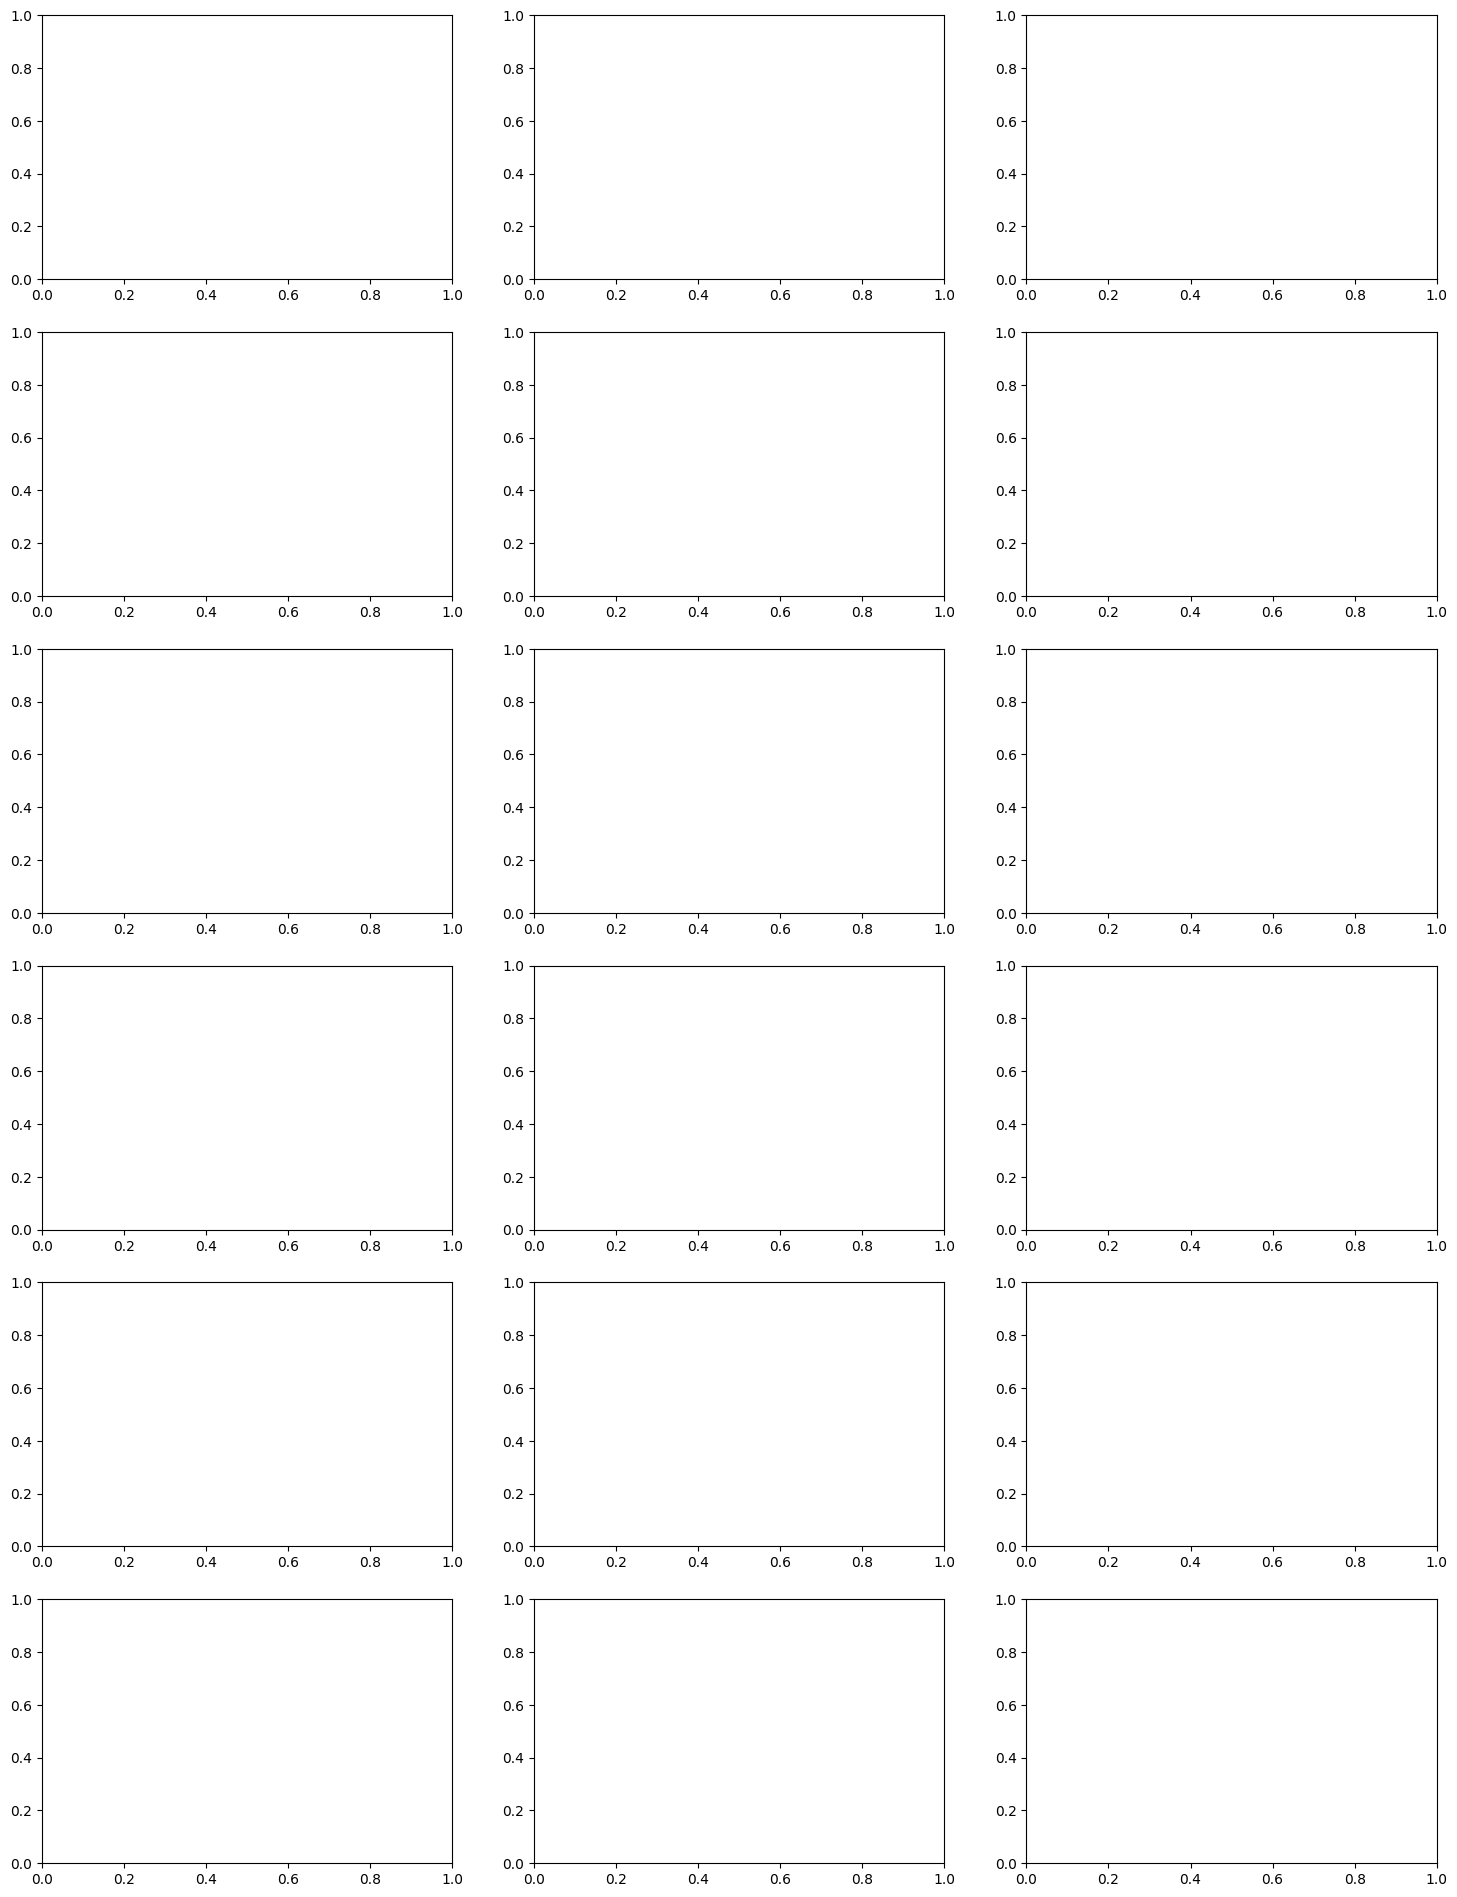

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import initializers

# tamanho da entrada
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET) 
N_MODELS = 10  # número de inicializações

seeds = np.random.choice(range(1, 10000), size=N_MODELS, replace=False)
neurons = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 19, 20, 21, 22, 23, 24, 25]
results = {}
excel_file = "resultados.xlsx"

for n in neurons:
    for i, s in enumerate(seeds):

        initializer = initializers.RandomNormal(seed=int(s))

        # cria modelo
        model = keras.models.Sequential([
            keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)),
            keras.layers.SimpleRNN(n, activation="tanh", kernel_initializer=initializer),
            keras.layers.Dense(OUTPUT_SIZE, activation="linear", kernel_initializer=initializer),  
        ])
        
        # salva pesos iniciais
        w0 = model.get_weights()

        # compila
        model.compile(loss="mean_squared_error", optimizer="adam")
        early_stopping_monitor = EarlyStopping(
            monitor='val_loss',
            patience=50,
            restore_best_weights=True
        )

        # treina
        history = model.fit(
            x_train, 
            y_train, 
            epochs=500,
            callbacks=[early_stopping_monitor],
            validation_data=(x_val, y_val),
            verbose=0
        )

        # salva pesos finais
        wf = model.get_weights()

       # avalia o modelo
        metrics = EvalModel(model)

        row = {
            "model": f"model_{n}_{i}",
            "Neurons": n,
            # ---- Pesos ----
            "W0": str([w.round(4).tolist() for w in w0]),
            "Wf": str([w.round(4).tolist() for w in wf]),
        }

        for name in TARGET:
            row.update({
                f"R2_Train_{name}": metrics[name]["R2_train"],
                f"MSE_Train_{name}": metrics[name]["MSE_train"],
                f"R2_Val_{name}": metrics[name]["R2_val"],
                f"MSE_Val_{name}": metrics[name]["MSE_val"],
                f"R2_Test_{name}": metrics[name]["R2_test"],
                f"MSE_Test_{name}": metrics[name]["MSE_test"],
            })

        df = pd.DataFrame([row])

        # salva/atualiza Excel incrementalmente
        try:
            # tenta abrir existente e adicionar linha
            old = pd.read_excel(excel_file)
            new_df = pd.concat([old, df], ignore_index=True)
            new_df.to_excel(excel_file, index=False)
        except FileNotFoundError:
            # se não existir, cria arquivo novo
            df.to_excel(excel_file, index=False)

        print(f"Modelo {i} treinado e salvo no Excel")